# Cast, Crew, and User Reviews
This notebook extracts the most frequently credited actors and directors, and visualizes how users rate films inside their individual reviews.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('../data/raw/letterboxd.db')

In [2]:
# 1. Top Directors
query_directors = """
SELECT person_name as Director, COUNT(film_id) as Films_Directed
FROM crew_members
WHERE crew_role = 'Director'
GROUP BY person_name
ORDER BY Films_Directed DESC
LIMIT 10;
"""
df_directors = pd.read_sql(query_directors, conn)
display("Top 10 Most Credited Directors:", df_directors)

'Top 10 Most Credited Directors:'

,Director,Films_Directed
0,Steven Spielberg,21
1,Martin Scorsese,17
2,Tim Burton,14
3,Ridley Scott,14
4,Wes Anderson,13
5,Quentin Tarantino,11
6,Hayao Miyazaki,11
7,David Lynch,11
8,David Fincher,11
9,Christopher Nolan,11


In [3]:
# 2. Top Actors
query_actors = """
SELECT actor_name as Actor, COUNT(film_id) as Appearances
FROM cast_members
GROUP BY actor_name
ORDER BY Appearances DESC
LIMIT 10;
"""
df_actors = pd.read_sql(query_actors, conn)
display("Top 10 Most Credited Actors:", df_actors)

'Top 10 Most Credited Actors:'

,Actor,Appearances
0,Stan Lee,59
1,Samuel L. Jackson,44
2,Frank Welker,44
3,Jess Harnell,43
4,Laraine Newman,42
5,Mickie McGowan,41
6,Sherry Lynn,37
7,Bob Bergen,35
8,Willem Dafoe,34
9,Jan Rabson,34


C:\Users\Dilhara Jayawardhana\AppData\Local\Temp\ipykernel_18116\1045454270.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_review_stars, x='star_rating', y='Count', palette='mako')


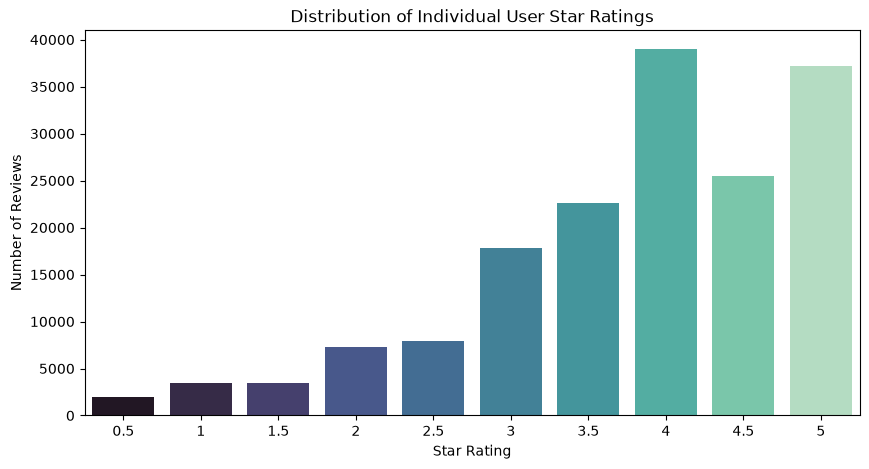

In [4]:
# 3. User Review Star Rating Distribution
# Excludes the 9,207 NULL ratings dynamically
query_review_stars = """
SELECT star_rating, COUNT(*) as Count
FROM film_reviews
WHERE star_rating IS NOT NULL AND star_rating != ''
GROUP BY star_rating
ORDER BY CAST(star_rating AS FLOAT) ASC;
"""
df_review_stars = pd.read_sql(query_review_stars, conn)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_review_stars, x='star_rating', y='Count', palette='mako')
plt.title('Distribution of Individual User Star Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.show()